In [357]:
# Initialize Otter
import otter
grader = otter.Notebook("hw3-task1.ipynb")

# Homework 3 - Task 1: Regularized Regression
## Comparing Ridge and Lasso for Predicting Building Heating Load

---

### Background

Regression problems can often contain dozens of predictors that are correlated with each other, redundant, or simply noise. Standard linear regression struggles in these settings because it spreads coefficient estimates across correlated features, inflates variance, and can overfit.

**Regularization** addresses this by adding a penalty to the least-squares objective. Both Ridge and Lasso start from the standard least squares criterion:

$$\text{RSS} = \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2$$

and adds a penalty term that shrinks coefficient estimates toward zero, trading a small increase in bias for a potentially large reduction in variance.

---

### Dataset

Buildings account for a significant portion of global energy consumption. This dataset contains energy performance data for **768 building configurations** simulated with Ecotect software, varying across eight architectural variables:

| Predictor | Description |
|---|---|
| Relative Compactness | How compact the building's shape is |
| Surface Area | Total external surface area |
| Wall Area | Total area of the walls |
| Roof Area | Area of the roof |
| Overall Height | Height of the building |
| Orientation | Direction the building faces (encoded numerically) |
| Glazing Area | Percentage of facade that is glass |
| Glazing Area Distribution | Distribution of glazing (even vs. concentrated) |

#### Response Variable

| Column | Description |
|---|---|
| Heating Load (Y1) | Continuous target — heating energy requirements |

*Cooling Load (Y2) is also in the dataset but is not used in this assignment.*


More information on the dataset used in this lab can be found [here](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

### Setup: Load libraries and read in data

Run the cell below to import all required packages and fetch the energy efficiency dataset from the UC Irvine Machine Learning Repository.

In [358]:
# Load Libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from ucimlrepo import fetch_ucirepo 
from sklearn.decomposition import PCA


### Step 1: Load the data

The cell below fetches the energy efficiency dataset from the UC Irvine Machine Learning Repository and converts it's contents to a dataframe. 

In [382]:
# Load data 
energy_efficiency = fetch_ucirepo(id=242)

feature_names = [
    "Relative Compactness", "Surface Area", "Wall Area", "Roof Area",
    "Overall Height", "Orientation", "Glazing Area", "Glazing Area Distribution"
]

df = energy_efficiency.data.features.copy()
df.columns = feature_names
df["Heating Load"] = energy_efficiency.data.targets.iloc[:, 0].values

df.head()

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84


### Step 2: Preprocess the data

Split the data into training and test sets using a 70/30 split and a `random_state` of 42. Then scale the data using `StandardScaler`. Name your scaled data `X_train_scaled` and `X_test_scaled`. 

In [360]:
# Define X and y
X = df[feature_names]
y = df["Heating Load"]

# Split 70/30
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                   test_size = 0.3, 
                                                   random_state = 42)

# Scaled 
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [361]:
grader.check("q1")

q1 results: All test cases passed!

### Step 3: Fit OLS Regression

Start with a plain OLS model as a baseline. Fit it on the training data. Calculate the MSE in a variable called `mse_ols` and inspect the coefficients.

In [ ]:
# Initalize 
lr = LinearRegression()
# Fit on training data 
lr.fit(X_train, y_train)
# Predict 
y_pred = lr.predict(X_test)

# Evaulate - MSE 
mse_ols = mean_squared_error(y_test, y_pred)

In [363]:
grader.check("q2")

q2 results: All test cases passed!

### Step 4: Fit Ridge with Cross-Validation

So far you've selected hyperparameters by manually looping over values and using `cross_val_score` to evaluate each one. `RidgeCV` does exactly the same thing. It's a convenience wrapper that handles that loop for you internally. Ft a `RidgeCV` model using the following lambda values: `np.logspace(-4,4, 100)` and`cv` of 10. Create a table comparing the coefficients for both OLS and Ridge. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Ridge Coefficient`. 

```python
# What you've done before:
for lambda in lambdas:
    ridge = Ridge(alpha=lambda)
    scores = cross_val_score(ridge, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
    ...

# What RidgeCV does under the hood (same idea, built in):
ridge_cv = RidgeCV(alphas=lambdas, cv=10, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train, y_train)
ridge_cv.alpha_   # Lambda with the best CV score
```

After calling `.fit()`, `ridge_cv` behaves like a regular fitted `Ridge` model. You can call `.predict()`, inspect `.coef_`, and so on. The best lambda is stored in `ridge_cv.alpha_`.

In [364]:
# Hyperparameter range 
lambdas = np.logspace(-4, 4, 100) # 100 values from -4 to 4

# Initalize 
ridge_cv = RidgeCV(alphas=lambdas, cv = 10, scoring='neg_mean_squared_error')

# Fit model
ridge_cv.fit(X_train_scaled, y_train)

# Predict 
ridge_pred = ridge_cv.predict(X_test_scaled)

# Pull out information  
ridge_lambda = ridge_cv.alpha_ # Lambda with best CV score 
ridge_mse = mean_squared_error(y_test, ridge_pred) # MSE

In [365]:
# Create a table of the features and coeffients from Ridge and OSL 
df_coef = pd.DataFrame({
    'Features': feature_names,
    'OSL Coef': lr.coef_, # Coeffient
    'Ridge Coef': ridge_cv.coef_
})

df_coef 

,Features,OSL Coef,Ridge Coef
0,Relative Compactness,-6.386753e+01,-6.352418
1,Surface Area,-8.736463e+09,-3.474392
2,Wall Area,8.736463e+09,0.816587
3,Roof Area,1.747293e+10,-3.797180
4,Overall Height,4.125574e+00,7.306373
5,Orientation,-2.357210e-02,-0.025299
6,Glazing Area,1.992667e+01,2.670852
7,Glazing Area Distribution,2.307234e-01,0.356417


In [366]:
grader.check("q3")

q3 results: All test cases passed!

<!-- BEGIN QUESTION -->

>**Q1: Is the penalty term doing its job?  How can you tell?**

Some of the coeffients in OSL vs Ridge are very different, such as surface, wall, and roof area. The ridge penality has reduced some of the OSL coeffients, pulling the betas closer to 0. This means the penality term is doing its job of reducing overfitting and handling correlated and irrelevant features. 

<!-- END QUESTION -->

### Step 5: Evaluate Ridge Model

Use the cross-validated ridge model from Step 4 to predict on the test set and compute MSE.

In [383]:
# Predict 
y_test_pred_rcv = ridge_cv.predict(X_test_scaled)

# Find MSE 
mse_rcv = mean_squared_error(y_test, y_test_pred_rcv) 

# Print statement
print(f"Test MSE:    {mse_rcv:.3f}")

Test MSE:    8.844


In [368]:
grader.check("q4")

q4 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 6: Ridge Coefficient Path

Now, create a plot looking at the coefficient values against lambda (similar to the one introduced in the [Regularization Notes)](https://meds-eds-232.github.io/EDS-232-course-website/notes/6_linear_model_selection_and_regularization/6_linear_model_selection_and_regularization-NOTES.html). Start by fitting a Ridge model for the values of lambda defined in Step 4. Then create a plot of the ridge regression coefficient profiles. Each feature should be plotted, with their coefficient value on the y axis and lambda values on the x axis. 

In [ ]:
# Range of hyperparameters 
lambdas = np.logspace(-4, 4, 100) # 100 values from -4 to 4

# Fit a Ridge model for the values of lambda 
mse_coef = []

for lam in lambdas: 
    # Initalize
    ridge = Ridge(alpha = lam)
    # Fit 
    ridge.fit(X_train_scaled, y_train)
    # Pull out coeff
    mse_coef.append(ridge.coef_) # Create a list of arrays of coeffients 

In [370]:
# Dataframe of coef per each lambda 
coef_df = pd.DataFrame(np.array(mse_coef), columns=feature_names, index=lambdas)
coef_df

,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution
0.000100,-6.686749,-3.701353,0.761170,-3.992326,7.216867,-0.026066,2.670032,0.356042
0.000120,-6.686713,-3.701328,0.761176,-3.992305,7.216877,-0.026066,2.670032,0.356042
0.000145,-6.686670,-3.701299,0.761183,-3.992280,7.216889,-0.026066,2.670032,0.356042
0.000175,-6.686618,-3.701263,0.761192,-3.992249,7.216903,-0.026066,2.670032,0.356043
0.000210,-6.686555,-3.701220,0.761202,-3.992212,7.216921,-0.026066,2.670033,0.356043
...,...,...,...,...,...,...,...,...
4750.810162,0.472359,-0.509052,0.436757,-0.710589,0.742765,0.009216,0.284071,0.079040
5722.367659,0.416889,-0.447783,0.371395,-0.618839,0.645147,0.008183,0.240385,0.067449
6892.612104,0.364960,-0.390929,0.314700,-0.535626,0.557158,0.007190,0.202829,0.057317
8302.175681,0.317176,-0.338971,0.265841,-0.461017,0.478660,0.006263,0.170713,0.048531


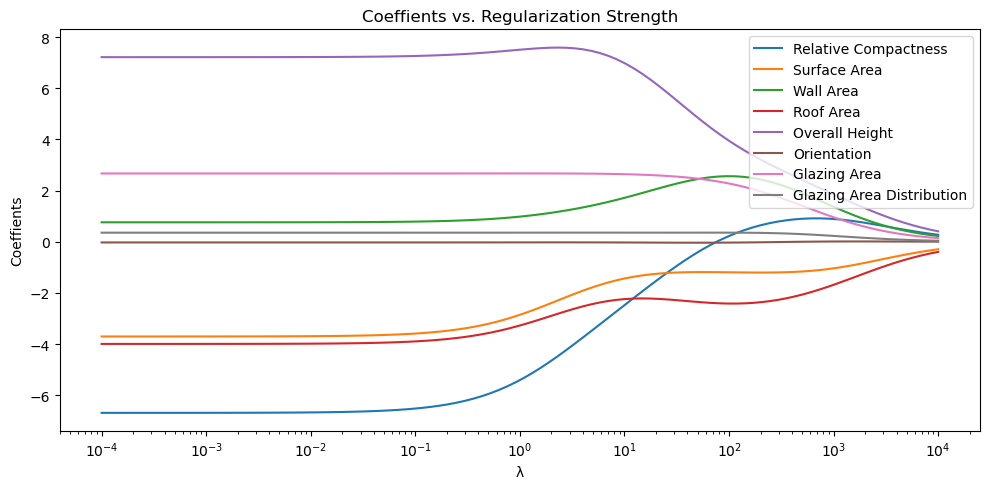

In [371]:
# Ridge regression coefficient profiles plt
plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_coef, label = feature_names)
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('Coeffients')
plt.title('Coeffients vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()

> **Q2: Which 2 predictors appear to be most important in the coefficient profile above? Explain your answer.**

Overall height and relative compactness have the largest absolute coeffients at low lambdas showing high importance. The predictors whose coeffients are consistently at or close to 0 are irrelvant/bad predictors for heating load, including orientation and glazing area distribution.

<!-- END QUESTION -->

### Step 7: Fit Lasso with Cross-Validation

Now fit a `LassoCV` model using the same lambda range and 10-fold CV. Create a table comparing the coefficients for both OLS and Lasso. Your table should include the following columns: `Feature`, `OLS Coefficient`, `Lasso Coefficient`. 

In [372]:
# Initalize 
lasso_cv = LassoCV(alphas=lambdas, 
                   cv = 10)
# Fit 
lasso_cv.fit(X_train_scaled, y_train)
# Look at coeffiencts 
lasso_cv.coef_

array([-6.4183303 , -6.23103457,  2.15252392, -1.04432391,  7.30915974,
       -0.0235928 ,  2.67019427,  0.35497087])

In [373]:
# Create table comparing OLS and lasso (and ridge) coeffients 
pd.DataFrame({
    'Features': feature_names, 
    'osl_coef': lr.coef_, 
    'lasso_coef': lasso_cv.coef_, 
    'ridge_coef': ridge_cv.coef_ # Wanted to add ridge to help answer the question below
})


,Features,osl_coef,lasso_coef,ridge_coef
0,Relative Compactness,-6.386753e+01,-6.418330,-6.352418
1,Surface Area,-8.736463e+09,-6.231035,-3.474392
2,Wall Area,8.736463e+09,2.152524,0.816587
3,Roof Area,1.747293e+10,-1.044324,-3.797180
4,Overall Height,4.125574e+00,7.309160,7.306373
5,Orientation,-2.357210e-02,-0.023593,-0.025299
6,Glazing Area,1.992667e+01,2.670194,2.670852
7,Glazing Area Distribution,2.307234e-01,0.354971,0.356417


In [374]:
grader.check("q5")

q5 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q3: Did lasso shrink the coefficients in the same way Ridge did? Comment on any differences.**

Lasso regression did shink the coeffients similar to the ridge regession. The main difference is the Roof, Wall, and Surface Area feature coeffients as they are all correlated to eachother. 

Lasso looked at all the correlated area features, selected surface area as the most important feature, and intensely penalized wall and roof area. On the other hand, ridge spread the correlation out between the surface and roof area coffients while deciding wall area was irrelative by minimizing its magnitide closer to 0. 

<!-- END QUESTION -->

### Step 8: Evaluate Lasso Model

Use the cross-validated lasso model from Step 7 to predict on the test set and compute MSE.

In [384]:
# Predict from lasso regession 
y_test_pred_lcv = lasso_cv.predict(X_test_scaled)

# Find MSE 
mse_lcv = mean_squared_error(y_test, y_test_pred_lcv)
# Print statement
print(f"Test MSE:    {mse_lcv:.3f}")

Test MSE:    8.842


In [376]:
grader.check("q6")

q6 results: All test cases passed!

<!-- BEGIN QUESTION -->

### Step 9: Compare Ridge and Lasso

Now that both models are fitted and evaluated, create the following: 
- A table comparing the Test MSE for OLS, Ridge CV, and Lasso CV.
- A singular plot to show how MSE responds to regularization strength across all alphas (for both lasso CV and ridge CV)
- A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV

Write 1 -2 sentences explaining the results for each plot.


*Hint: Refer back to Lab 5 for help with code on both these plots!*

In [377]:
# (1) Table comparing test MSE scores 
pd.DataFrame({
    'Regessions': ['OLS', 'Ridge', 'Lasso'],
    'mse values': [mse_ols, mse_rcv, mse_lcv]
})


,Regessions,mse values
0,OLS,8.840180
1,Ridge,8.843961
2,Lasso,8.841571


/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.397e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.924e+01, tolerance: 5.455e+00
  model = cd_fast.enet_coordinate_descent(
/opt/anaconda3/envs/eds232-env/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:628: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasi

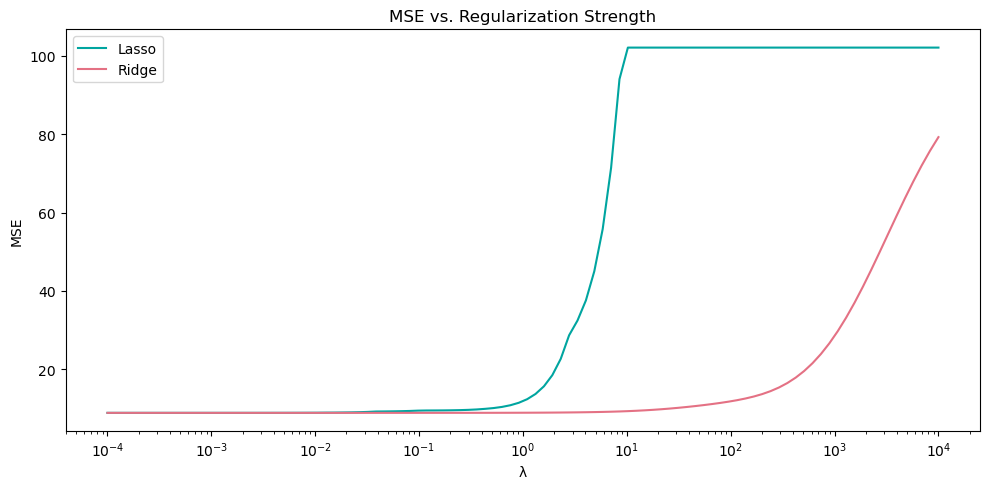

In [378]:
# (2) Plot showing MSE reponse to regularization strength acoss lambdas 
# Empty lists 
mse_lasso = []
mse_ridge = []

# MSE over lamda ranges 
for lam in lambdas: 
    # Initalize
    lasso = Lasso(alpha = lam) 
    ridge = Ridge(alpha = lam)
    
    # Fit 
    lasso.fit(X_train_scaled, y_train)
    ridge.fit(X_train_scaled, y_train)

    # Evaluate on test set 
    # make predictions, calc MSE, append value to empy list for all values of lambda
    mse_lasso.append(mean_squared_error(y_test, lasso.predict(X_test_scaled))) 
    mse_ridge.append(mean_squared_error(y_test, ridge.predict(X_test_scaled))) 


# Plot  
plt.figure(figsize=(10, 5))
plt.plot(lambdas, mse_lasso, label='Lasso', color='#00a5a0')
plt.plot(lambdas, mse_ridge, label='Ridge', color='#e47184')
plt.xscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.title('MSE vs. Regularization Strength')
plt.legend()
plt.tight_layout()
plt.show()


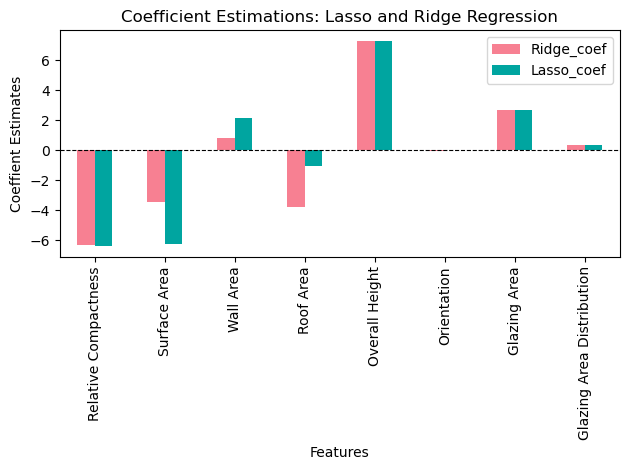

In [379]:
# (3) A bar plot showing how coefficient estimates differ for OLS, Lasso CV, and Ridge CV
# Create table of coeffients 
coeffients = pd.DataFrame({
    'Ridge_coef': ridge_cv.coef_,
    'Lasso_coef': lasso_cv.coef_
}, index=feature_names)

# Plot 
ax = coeffients.plot(kind = 'bar', color = ['#f78092', '#00a5a0'], title = "Coefficient Estimations: Lasso and Ridge Regression")
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel("Coeffient Estimates")
ax.set_xlabel('Features')
#ax.set_xticklabels(coeffients.index, rotation=45)

plt.tight_layout()
plt.show()


> **Q4: Which model would you pick for this dataset? Why?**

The mean squared error for both regression models are very similar, differing by 0.00239. Seen in MSE vs Regularization Strength plot, Lasso is more sensistive to Lambda as it agressely zeros out coeffients. Ridge regression spreads the penalty smoothly between the correlating features and, thus, is more forgiving. Therefore, I would choose ridge regresssion. 
Important note- at low lambdas, ridge and lasso are preforming like the OLS model, illustrating regularization is weak in this senario. 

<!-- END QUESTION -->

---

## Part 2: Principal Components Regression (PCR)

### Background

**Principal Component Analysis (PCA)** is a dimensionality-reduction technique whose goal is to *capture as much about the data as possible in as few dimensions as possible*. It does this by finding a new set of axes — the **principal components (PCs)** — where:

- **PC1** points in the direction of **maximum variance** in the data.
- **PC2** is orthogonal to PC1 and points in the next direction of greatest remaining variance.
- Each subsequent component is orthogonal to all previous ones and explains less variance.

Each observation gets a new coordinate in this rotated space called a **score**. The contribution of each original feature to a PC is called a **loading**.

The **Proportion of Variance Explained (PVE)** measures each component's share of total variance. A common rule of thumb is to keep enough components to explain **90–95% of the total variance**.

---

**Principal Components Regression (PCR)** connects unsupervised PCA structure to a supervised response:

1. **Standardize** the predictors.
2. **Compute** the principal components.
3. **Project** the observations onto *M* components (the scores).
4. **Fit OLS** on the projected data (the *M* scores) rather than the original features.

The key assumption is that *"directions in which the predictors show the most variation are often also the directions most strongly associated with the response."* By discarding low-variance components we reduce noise, not signal.

---

**How PCR differs from Ridge and Lasso:**

| | Ridge | Lasso | PCR |
|---|---|---|---|
| Mechanism | L2 penalty shrinks all coefs | L1 penalty can zero out coefs | Drops low-variance directions |
| Variable selection? | No | Yes (exact zeros) | No — uses linear combinations of *all* predictors |
| Tuning parameter | λ (penalty strength) | λ (penalty strength) | *M* (number of components) |

Unlike Lasso, **PCR cannot perform variable selection** — every original feature still contributes to each PC. Lasso tends to outperform PCR when truly irrelevant predictors exist, because it can set those coefficients exactly to zero.

### Step 10: Fit PCA and Inspect Explained Variance

In the cells below:
1. Fit a `PCA` object on `X_train_scaled` using all 8 components.
2. Store the explained variances in a variable called `explained_var` and the cumulative variance in a variable called `cumulative_var`. Print a table showing each component's individual and cumulative explained variance (%).
3. Create a plot with:
   - A **bar chart** showing the individual explained variance (%) for each component.
   - A **line plot** overlaid showing the cumulative explained variance (%).

Use the plot to identify where cumulative variance first reaches ~90% and where the "elbow" in the bar chart occurs. You'll use this to choose *k* in the next step.

After fitting a `PCA` object, two attributes give you the variance information you need:

```python
pca.explained_variance_ratio_      # Array of length n_components
                                   # Each value = fraction of total variance explained by that PC
                                   # E.g. [0.45, 0.30, ...] means PC1 explains 45%, PC2 explains 30%

np.cumsum(pca.explained_variance_ratio_)   # Cumulative variance total used for finding the "elbow" and checking how many components hit the 90% threshold
                                           
```

In [380]:
# Initalize 
pca = PCA(n_components=8)
# fit 
pca_full = pca.fit(X_train_scaled)

# Explained variance 
explained_var = pca.explained_variance_ratio_
# Cumulative variance 
cumulative_var = np.cumsum(pca.explained_variance_ratio_)

In [385]:
# Create a table with Explained & Cumculative variance 
pca_df= pd.DataFrame({
  'component': ['PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8'],
  'explained_var' : explained_var, 
  'cumulative_var' : cumulative_var,
})
pca_df

,component,explained_var,cumulative_var
0,PC1,4.629048e-01,0.462905
1,PC2,1.563182e-01,0.619223
2,PC3,1.497484e-01,0.768971
3,PC4,1.243148e-01,0.893286
4,PC5,9.966322e-02,0.992949
5,PC6,6.477268e-03,0.999427
6,PC7,5.733790e-04,1.000000
7,PC8,2.730130e-32,1.000000


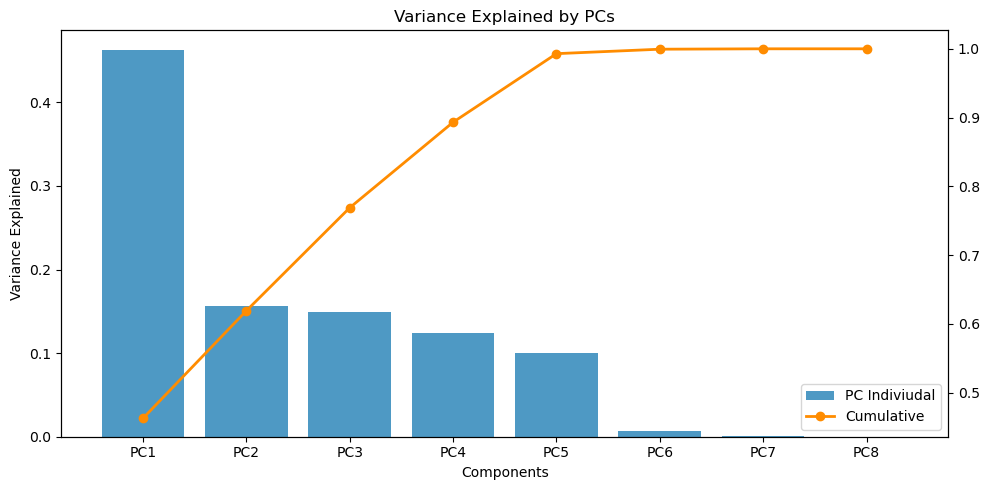

In [ ]:
# Bar chart showing the individual explained variance (%) for each component
# Line plot overlaid showing the cumulative explained variance (%)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Bar chart on ax1
ax1.bar(pca_df['component'], pca_df['explained_var'], color = "#4e99c4", label='PC Indiviudal')

# Line plot (second y-axis sharing same x)
ax2 = ax1.twinx()
ax2.plot(pca_df['component'], pca_df['cumulative_var'], color = "darkorange",  marker='o', linewidth=2, label='Cumulative')

ax1.set_xlabel("Components")
ax1.set_ylabel("Variance Explained")
ax1.set_title("Variance Explained by PCs")

# Combind Legends 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc = 'lower right')

plt.tight_layout()
plt.show()

In [ ]:
grader.check("q7")

q7 results: All test cases passed!

<!-- BEGIN QUESTION -->

> **Q5: How many principal components does it take to explain at least 90% of the variance in the features?**

It takes 4 components to explain 89.3% of the variance in the features, and 5 components to explain 99.3% of the variance in the features. 

<!-- END QUESTION -->

### Step 11: Fit the Final PCR Model

PCR follows four concrete steps:

1. **Standardize the predictors** (mean 0, SD 1) (done in Step 2 with `StandardScaler`)
2. **Compute the principal components** of the standardized predictors (done in Step 10 with `PCA`)
3. **Project each observation onto the first *k* components** ( `pca_final.transform()` gives you the scores)
4. **Fit OLS of y on this new projected data** (`LinearRegression` on the PC scores)

You have already done steps 1 and 2. Now, set `best_k` based on the "elbow" or ~90% cumulative variance threshold from your plot above. Then carry out steps 3 and 4 by initializing `PCA(n_components = best_k`), transforming with `X_train_scaled` and `X_test_scaled`, and then fitting a `LinearRegression` with this transformed data. 

In [ ]:
# Setting k based on the elbow / ~90% cumulative variance threshold in the plot above - PC 5 
best_k = 5 

# Initalize & fit PCA
pca_final = PCA(n_components=best_k).fit(X_train_scaled)

# Transforming with X scaled 
X_train_pca = pca_final.transform(X_train_scaled)
X_test_pca  = pca_final.transform(X_test_scaled)

# Initalize & Fit linear regression (with transformed data)
ols_pcr = LinearRegression().fit(X_train_pca, y_train)

# Evaluate  
y_pred_pcr = ols_pcr.predict(X_test_pca)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)

<!-- BEGIN QUESTION -->

> **Q6: What value of k did you pick? Why?**

K = 5 is where the Principle Comonent Analsis cumulative variance surpases 90%. Therefore, I choose a best K of 5. 

<!-- END QUESTION -->

<!-- BEGIN QUESTION -->

---

## Final Comparison: OLS, Ridge, Lasso, and PCR

Now that all four models have been fitted and evaluated, bring the results together.

### Step 12: Summary Table

Build a summary table comparing the test MSE across all four models. Your table should have three columns: `Model`, `Tuning Parameter` (specify the lambda/ number of components chosen), and `Test MSE`. 

In [ ]:
pd.DataFrame({
    'Model': ['Linear Regression', 'Lasso', 'Ridge', 'PCA'],
    'Tuning Paramter': ['NA', lasso_cv.alpha_, ridge_cv.alpha_, best_k],
    'Test_MSE':[mse_ols, mse_lcv, mse_rcv, mse_pcr]
})


,Model,Tuning Paramter,Test_MSE
0,Linear Regression,NA,8.840180
1,Lasso,0.00163,8.841571
2,Ridge,0.205651,8.843961
3,PCA,5,12.703310


For PCR to perform well a key assumption must hold: the directions that show the most variation in the predictors are also the directions most strongly associated with the response. Lasso and ridge aim to shrink the coefficients associated with predictors wit little predictive value.

> **Q7: Comment on the results in the table above. Which model performs best? Are the differences meaningful, or do the models perform similarly? What might explain the pattern you see?**

Linear regression has the smallest MSE, with ridge and lasso following by 0.001 and 0.004. PCA is an outliear and thus a clear bad regression model for this data. These MSE values towards linear regression performing the best. Yet, linear, ridge, and lasso all have similar low mean square error which means the regularization is barley doing anything. This suggest the data doesn't have multicolinearity or overfitting problem that regularization needs to fix. PCA has the highest error because it dropped three important predictors. 

<!-- END QUESTION -->



---

Run the cell below to receive credit for the augotraded questions. 

In [ ]:
grader.check_all()

q1 results: All test cases passed!

q2 results: All test cases passed!

q3 results: All test cases passed!

q4 results: All test cases passed!

q5 results: All test cases passed!

q6 results: All test cases passed!

q7 results: All test cases passed!